
=== PASCHEN-1D RUN SUMMARY ===
run_name: argon_cathode_quantum_plus_mg_test
geometry: L=0.0035 m, A=0.000286 m^2, l=0 m, eps_r=4.3
plasma: gas=argon, p_Torr=2.88, n0=1e+14 m^-3
grid/time: Nx=200, Nt=2000000, T_total=2e-05 s, dx=1.75879e-05 m, dt=1e-11 s
waveform: type=step, V_peak=130 V, t_on=0 s, t_off=2e-05 s
circuit: type=R0_Cp_Rm, scheme=explicit_euler, R0=76.4, C_s=0, L_s=0, C_p=2.06e-10, L_p=0, R_m=1e+06
numerics: kt_limiter_theta=1.1
boundary-modes: anode(i=zero_density, e=implicit_drift_closure), cathode(i=implicit_drift_closure, e=electron_emission)
sources: volume=True, ionization=True, recombination=True
emission: enabled=True, material_mode=shared, anode=[], cathode=['mg', 'quantum_pulse'], electrodes=(anode=False, cathode=True), to_circuit=True
diagnostics-temporal: enabled=True, mode=grouped (3 groups), window=[None,None]
diagnostics-spatial: enabled=True, mode=separate (2 quantities), t_samples=final_time_only, x_unit=cm

Precomputing quantum photoemission pulse (cathod

Building photoemission pulse (cathode):   0%|          | 0/201 [00:00<?, ?it/s]

Time stepping: 100%|████████████████| 1999999/1999999 [14:14<00:00, 2340.61it/s]


Elapsed time: 854.494322 s


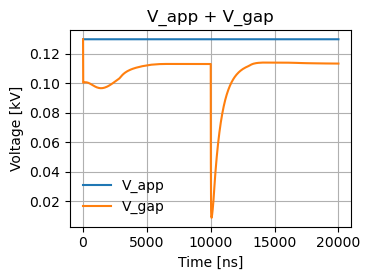

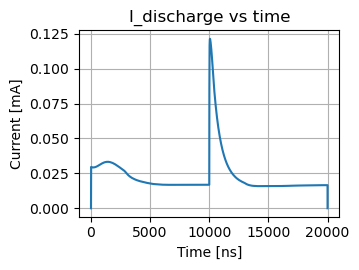

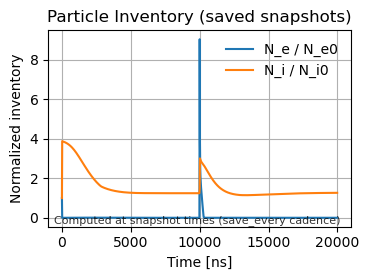

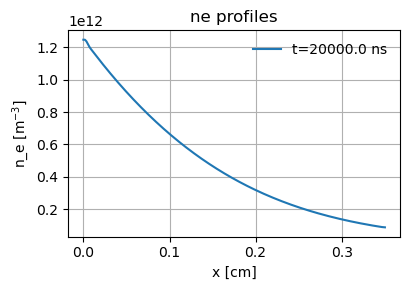

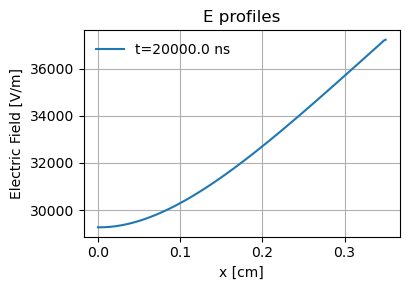

In [1]:
"""
Notebook driver for paschen_1d

This cell:
    - Constructs a SimulationConfig instance,
    - Runs the 1D drift-diffusion-Poisson simulation,
    - Runs diagnostics selected in cfg.diagnostics.

Use config.py to choose temporal/spatial diagnostics and requested times.
"""

# Simulation core
from config import SimulationConfig
from paschen_1d import run_simulation, run_configured_diagnostics
from physics import make_voltage_waveform

# --------------------------------------------------------------------
# 1. Build configuration
# --------------------------------------------------------------------
# You can override defaults here. Example:
#   cfg = SimulationConfig(
#       run_name="ak_zero_bias_baseline",
#       waveform_type="dc",
#       V_peak=0.0,
#   )
cfg = SimulationConfig()

# --------------------------------------------------------------------
# 2. Run the simulation
# --------------------------------------------------------------------
state = run_simulation(cfg)

# --------------------------------------------------------------------
# 3. Run configured diagnostics (temporal + spatial)
# --------------------------------------------------------------------
V_app_func = make_voltage_waveform(cfg)
run_configured_diagnostics(cfg, state, V_app_func)

# Optional: direct access to final fields for custom analysis
# ne_final = state.ne_final
# ni_final = state.ni_final
# phi_final = state.phi_final
# E_final = state.E_final
